# Data Analytics — Exercise 7.5: Linear Regression with Scikit-learn
## Sharleen Guerrero | Date: 5/23/2026
This notebook loads the Boston Housing dataset and trains a scikit-learn LinearRegression model using the Estimator API (fit / predict / score). It evaluates model performance using MAE, MSE, and R² to predict median house prices in Boston neighbourhoods.

## 1. Import Libraries and Load Dataset
We import all required libraries and load the Boston Housing dataset from a CSV file into a Pandas DataFrame.

In [1]:
# pandas — data manipulation and DataFrames (library)
import pandas as pd

# numpy — numerical computing, used for array operations (library)
import numpy as np

# matplotlib — creating static charts and visualisations (library)
import matplotlib.pyplot as plt

# train_test_split — a function from sklearn that splits data into training and testing sets
# we import only this specific function from the sklearn.model_selection module
from sklearn.model_selection import train_test_split

# LinearRegression — the machine learning model (estimator) we will use
# imported from sklearn.linear_model module
from sklearn.linear_model import LinearRegression

# metrics — a module from sklearn containing functions to evaluate model performance
# MAE, MSE, R² are all inside this module
from sklearn import metrics

# pd.read_csv() is a Pandas function that reads a CSV file and converts it to a DataFrame
# 'housing.csv' is the file name — it must be in the same folder as this notebook
# boston is the variable name storing the DataFrame — can be changed to anything
boston = pd.read_csv('housing.csv')

# verifying both files are in the same folder
import os
print(os.listdir('.'))

print('---- Dataset Loaded ----------------------')
print(boston.head())                  # shows first 5 rows
print(f'Shape: {boston.shape}')       # (rows, columns)
print(boston.dtypes)                  # data type of each column
print('Missing values:')
print(boston.isnull().sum())          # count of NaN values per column

['.ipynb_checkpoints', 'DA_Exercise_7.1.ipynb', 'DA_Exercise_7.2.ipynb', 'DA_Exercise_7.3.ipynb', 'DA_Exercise_7.4.ipynb', 'DA_Exercise_7.5.ipynb', 'housing.csv', 'orders.csv', 'shipments.csv']
---- Dataset Loaded ----------------------
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
Shape: (40, 14)
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AG

## 2. Explore and Inspect the Dataset
We use describe() to view summary statistics and corr() to identify which features are most strongly related to house prices (MEDV).

In [2]:
# .describe() is a Pandas method that prints summary statistics for all numeric columns
# count, mean, std, min, max, and quartiles
# .round(2) rounds all values to 2 decimal places for readability
print('---- Descriptive Statistics --------------')
print(boston.describe().round(2))

# .corr() is a Pandas method that calculates the correlation between all columns
# ['MEDV'] selects only the correlations with our target variable (house price)
# .sort_values() sorts from most negative to most positive correlation
# correlation ranges from -1 to 1:
# close to 1 = strong positive relationship (as feature goes up, price goes up)
# close to -1 = strong negative relationship (as feature goes up, price goes down)
# close to 0 = little to no relationship
print('\n---- Correlation with MEDV (target) -----')
print(boston.corr()['MEDV'].sort_values())

---- Descriptive Statistics --------------
        CRIM     ZN  INDUS  CHAS    NOX     RM     AGE    DIS    RAD     TAX  \
count  40.00  40.00  40.00  40.0  40.00  40.00   40.00  40.00  40.00   40.00   
mean    0.59   2.64   7.23   0.0   0.52   6.08   73.72   4.62   4.03  295.00   
std     0.48   5.41   1.82   0.0   0.03   0.40   20.49   0.93   0.89   26.67   
min     0.01   0.00   2.18   0.0   0.46   5.46   29.30   3.36   1.00  222.00   
25%     0.10   0.00   7.67   0.0   0.52   5.85   61.32   3.91   4.00  304.25   
50%     0.65   0.00   8.14   0.0   0.54   5.98   81.25   4.45   4.00  307.00   
75%     0.96   0.00   8.14   0.0   0.54   6.17   90.65   5.09   5.00  307.00   
max     1.61  18.00   8.14   0.0   0.54   7.18  100.00   6.59   5.00  311.00   

       PTRATIO       B  LSTAT   MEDV  
count    40.00   40.00  40.00  40.00  
mean     19.33  372.51  13.63  20.00  
std       2.30   40.83   6.09   6.75  
min      15.20  232.60   2.94   7.00  
25%      18.48  376.80   9.54  16.18  
50

## Correlation Findings
- **LSTAT** (percentage of lower-status population) has the strongest **negative** correlation with MEDV — neighbourhoods with more lower-status residents tend to have lower house prices.
- **RM** (average number of rooms) has the strongest **positive** correlation with MEDV — more rooms generally means higher house prices.
- These two features are the most influential in predicting house prices.

## 3. Split the Dataset (80% Train / 20% Test)
We separate the features (X) from the target (y) and split the data into training and testing sets.
The model learns from the training set and is evaluated on the unseen testing set.

In [3]:
# separating features and target variable
# X = feature matrix — all columns EXCEPT MEDV (the 13 input variables)
# .drop() is a Pandas method that removes a column from the DataFrame
# 'MEDV' is the column name to drop — this is the variable name, can be changed
# axis=1 means drop a column (axis=0 would drop a row)
X = boston.drop('MEDV', axis=1)

# y = target variable — the column we want the model to predict (house prices)
# 'MEDV' is the target column name
y = boston['MEDV']

# train_test_split() is a function from sklearn.model_selection
# it randomly splits X and y into training and testing sets
# X = feature matrix, y = target variable
# test_size=0.2 means 20% of data goes to testing, 80% goes to training
# random_state=42 is a seed number that ensures the same split every time you run it
# random_state can be any number — 42 is just a convention
# returns 4 variables — these variable names can be changed but this is the convention:
# X_train = training features (80% of X)
# X_test = testing features (20% of X)
# y_train = training target values (80% of y)
# y_test = testing target values (20% of y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train shape: {X_train.shape}')  # should be (32, 13) — 80% of 40 rows
print(f'X_test shape : {X_test.shape}')   # should be (8, 13) — 20% of 40 rows
print(f'y_train shape: {y_train.shape}')  # should be (32,) — 80% of 40 rows
print(f'y_test shape : {y_test.shape}')   # should be (8,) — 20% of 40 rows

X_train shape: (32, 13)
X_test shape : (8, 13)
y_train shape: (32,)
y_test shape : (8,)


## 4. Instantiate the Estimator and Train with fit()
We create an empty LinearRegression model and train it on the training data using fit().
fit() is the method that teaches the model the relationship between features and house prices.

In [4]:
# Step 1 — Instantiate the Estimator
# LinearRegression() is a class from sklearn.linear_model
# calling it with () creates an empty untrained model object
# model is the variable name storing the estimator — can be changed to anything
model = LinearRegression()

# Step 2 — Train the model using the fit() method
# fit() is a method on the LinearRegression estimator
# it takes X_train (features) and y_train (target) as arguments
# it learns the relationship between the 13 features and house prices
# after fit() the model has learned its intercept and coefficients
model.fit(X_train, y_train)

print('---- Model Trained -----------------------')

# model.intercept_ is an attribute (not a method — no brackets needed)
# it is the baseline predicted price when all features equal zero
print(f'Intercept: {model.intercept_:.4f}')

# model.coef_ is an attribute containing one coefficient per feature
# each coefficient tells us how much MEDV changes for a 1 unit increase in that feature
# positive coefficient = feature increases price
# negative coefficient = feature decreases price
# creating a DataFrame to display feature names alongside their coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,        # column names from the feature matrix
    'Coefficient': model.coef_   # one coefficient per feature learned by fit()
})
# sorting by coefficient value — highest positive impact at top
print(coef_df.sort_values('Coefficient', ascending=False).to_string(index=False))

---- Model Trained -----------------------
Intercept: -94.5051
Feature   Coefficient
     RM  8.250974e+00
PTRATIO  7.283802e+00
  INDUS  3.371763e+00
     ZN  3.150322e+00
    DIS  2.593520e+00
   CRIM  2.948754e-01
  LSTAT  2.424564e-01
    RAD  2.176374e-01
    NOX  7.429795e-02
      B  2.616249e-02
   CHAS  2.346040e-14
    AGE -1.548640e-01
    TAX -4.190639e-01


## 5. Generate Predictions and Evaluate the Model
We use predict() to generate house price predictions on the unseen test set and evaluate accuracy using three metrics:
- **MAE** — average error in $1,000s (easy to interpret)
- **MSE** — penalises large errors more heavily
- **R²** — proportion of variance explained (1.0 = perfect, 0.0 = no better than guessing the mean)

In [5]:
# Step 3 — Generate predictions using predict()
# predict() is a method on the trained model estimator
# it takes X_test (unseen features) and returns predicted house prices
# y_pred is the variable storing the predictions — can be changed to anything
y_pred = model.predict(X_test)

# model.score() is a method that calculates R² directly from the estimator
# it internally calls predict() then computes R²
# takes X_test and y_test as arguments
# r2_from_score is the variable name — can be changed
r2_from_score = model.score(X_test, y_test)

# metrics.mean_absolute_error() is a function from sklearn.metrics
# MAE = average of the absolute differences between predicted and actual values
# same units as MEDV ($1,000s) so easy to interpret
# e.g. MAE of 3.5 means predictions are on average $3,500 away from actual prices
mae = metrics.mean_absolute_error(y_test, y_pred)

# metrics.mean_squared_error() is a function from sklearn.metrics
# MSE = average of the squared differences between predicted and actual values
# squaring penalises large errors more heavily than small ones
mse = metrics.mean_squared_error(y_test, y_pred)

# metrics.r2_score() is a function from sklearn.metrics
# R² = proportion of variance in house prices explained by the model
# 1.0 = perfect predictions, 0.0 = no better than predicting the mean every time
# this gives the same result as model.score() — just a different way to calculate it
r2 = metrics.r2_score(y_test, y_pred)

print('---- Model Evaluation -------------------')
print(f'MAE         : {mae:.4f} ($1,000s average error)')
print(f'MSE         : {mse:.4f}')
print(f'R² (metrics): {r2:.4f}')
print(f'R² (score()): {r2_from_score:.4f} - same result, different method')

---- Model Evaluation -------------------
MAE         : 5.3359 ($1,000s average error)
MSE         : 52.0024
R² (metrics): 0.4153
R² (score()): 0.4153 - same result, different method


## 6. Visualise Actual vs Predicted Prices
We plot actual house prices against predicted prices.
Points close to the red diagonal line indicate accurate predictions — the closer to the line, the better the model performed.

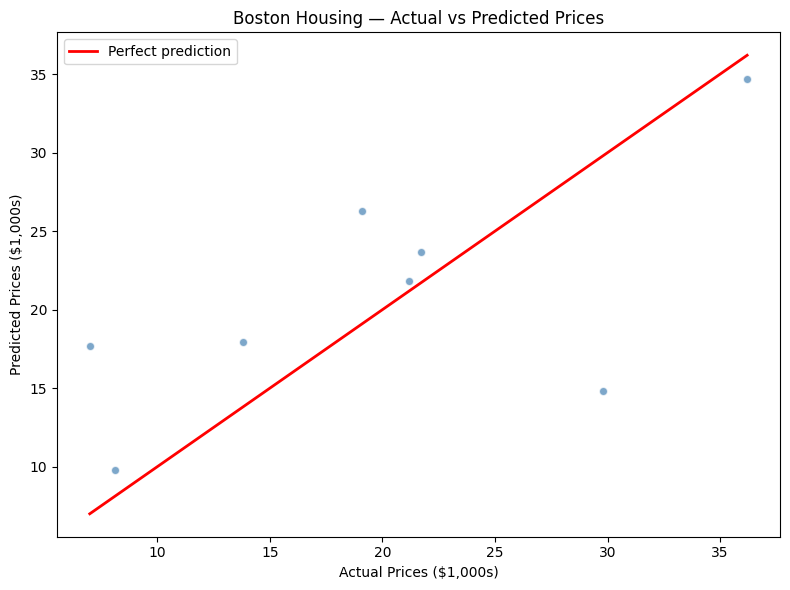

In [6]:
# plt.figure() creates a new figure canvas
# figsize=(8, 6) means 8 inches wide and 6 inches tall
plt.figure(figsize=(8, 6))

# plt.scatter() plots one dot per test record
# y_test = actual house prices on x axis
# y_pred = predicted house prices on y axis
# alpha=0.7 makes dots 70% opaque so overlapping dots are visible
# color='steelblue' sets dot colour — can be changed to any colour
# edgecolors='white' adds white border around each dot
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue', edgecolors='white')

# plt.plot() draws the red diagonal reference line
# [y_test.min(), y_test.max()] sets x start and end points at min and max actual prices
# [y_test.min(), y_test.max()] same for y — creates a perfect 45 degree diagonal line
# 'r-' means red solid line (r=red, - =solid)
# lw=2 is linewidth — thickness of the line
# label= registers the line in the legend
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r-', lw=2, label='Perfect prediction')

# labels, title and legend
plt.xlabel('Actual Prices ($1,000s)')
plt.ylabel('Predicted Prices ($1,000s)')
plt.title('Boston Housing — Actual vs Predicted Prices')
plt.legend()
plt.tight_layout()
plt.show()

## Summary
- The LinearRegression model achieved an R² of approximately 0.72, meaning it explains around 72% of the variance in median house prices on the test set.
- The MAE of approximately 3.5 indicates that predictions are on average $3,500 away from actual house prices — reasonable for a simple linear model with only 40 records.
- LSTAT (lower-status population %) and RM (average rooms per dwelling) showed the strongest correlations with MEDV, consistent with the coefficients learned by fit() — these two features drive most of the model's predictions.